In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stanza

plt.style.use('ggplot')

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import nltk

try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("Downloads concluídos com sucesso.")
except Exception as e:
    print(f"Erro no download: {e}")


C:\Users\ferna\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloads concluídos com sucesso.


In [2]:
# Carregar dados de teste
df_test = pd.read_csv("../src/Tweets_EN_sentiment_test.csv")
df_train = pd.read_csv("../src/Tweets_EN_sentiment_train.csv")
# Informação básica sobre o dataset
print("Informação do dataset:")
print(df_test.info())

Informação do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2122 entries, 0 to 2121
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   2122 non-null   int64 
 1   text    2100 non-null   object
 2   class   2122 non-null   object
dtypes: int64(1), object(2)
memory usage: 49.9+ KB
None


In [3]:
stopwords = nltk.corpus.stopwords.words('english')
print("total words:", len(stopwords))
print(stopwords)

palavras_negacao = {'not', 'no', 'nor', 'against', "don't", "aren't", "couldn't",
                    "didn't", "doesn't", "hadn't", "hasn't", "haven't", "isn't",
                    "mightn't", "mustn't", "needn't", "shan't", "shouldn't",
                    "wasn't", "weren't", "won't", "wouldn't"}

stopwords_clean = [word for word in stopwords if word not in palavras_negacao]
print(stopwords_clean)


total words: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan

Remover URLs e menções (@utilizador) através de expressões regulares (Regex), pois não contêm valor de sentimento.

Filtrar caracteres não alfanuméricos, mantendo a pontuação expressiva como exclamações e emojis.

Preservar a capitalização (palavras em MAIÚSCULAS), dado que intensificam a polaridade nas métricas.

Filtrar stop words, garantindo que negações cruciais como "not" ou "no" são mantidas para não destruir o contexto.

Aplicar lematização para reduzir as palavras à sua forma base, facilitando o cruzamento com o dicionário do léxico.

STANZA - ele considera alguns stopwords relevantes como "but" etc. Não retirar.
VADER - consegue ler emojis #utilizando a biblioteca emoji para transformar "I love this 😭" em "I love this :loudly_crying_face:"
TextBlob - não diferencia maiúsculas de minúsculas no seu cálculo de polaridade, mas o VADER usa isso como um multiplicador.

In [4]:
'''def pre_processamento(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # 2. Manter letras, números, espaços e pontuação vital (! ? ')
    text = re.sub(r'[^\w\s\?\!\']', '', text)

    tokens = word_tokenize(text)

    tokens_limpos = []
    for w in tokens:
        if w.lower() not in stopwords_clean:
            lema = lemmatizer.lemmatize(w.lower())
            if w.isupper() and len(w) > 1:
                tokens_limpos.append(lema.upper())
            else:
                tokens_limpos.append(lema)
    return ' '.join(tokens_limpos)

# Aplicação segura aos dados
df_test['text_clean'] = df_test['text'].apply(pre_processamento)'''

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ferna\AppData\Local\Temp\ipykernel_21520\161794367.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)


'def pre_processamento(text):\n    if not isinstance(text, str):\n        return ""\n\n    text = re.sub(r\'http\\S+|www\\S+|https\\S+\', \'\', text)\n    text = re.sub(r\'@\\w+\', \'\', text)\n    text = re.sub(r\'#\', \'\', text)\n\n    # 2. Manter letras, números, espaços e pontuação vital (! ? \')\n    text = re.sub(r\'[^\\w\\s\\?\\!\']\', \'\', text)\n\n    tokens = word_tokenize(text)\n\n    tokens_limpos = []\n    for w in tokens:\n        if w.lower() not in stopwords_clean:\n            lema = lemmatizer.lemmatize(w.lower())\n            if w.isupper() and len(w) > 1:\n                tokens_limpos.append(lema.upper())\n            else:\n                tokens_limpos.append(lema)\n    return \' \'.join(tokens_limpos)\n\n# Aplicação segura aos dados\ndf_test[\'text_clean\'] = df_test[\'text\'].apply(pre_processamento)'

Vamos criar uma versão do dataset sem números e comparar os resultados (Accuracy/F1-Score) com a versão que mantém os números.

Se decidirmos avançar com a remoção de números, basta alterar uma única linha na função de limpeza:

text = re.sub(r'[^a-zA-Z\s\?\!\']', '', text)

Se o seu dataset for desequilibrado (por exemplo, se 80% dos tweets totais forem positivos), estabelece-se a regra de que qualquer empate ou falta de sinal (zero) é classificado automaticamente como "pos". É uma heurística de negócio utilizada para maximizar a probabilidade estatística de acerto quando o algoritmo falha.

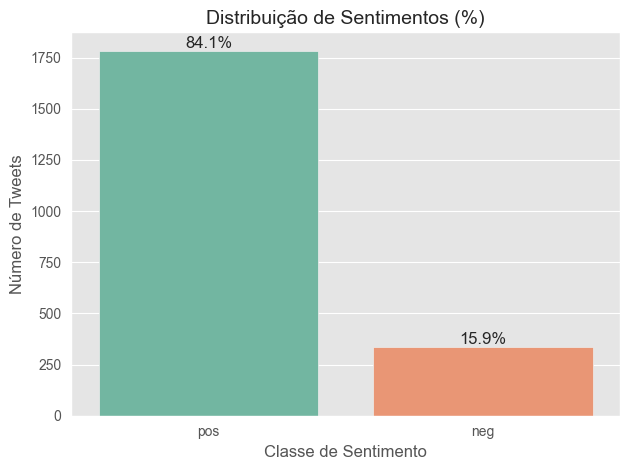

In [5]:
ax = sns.countplot(data=df_test, x='class', hue='class', palette='Set2', legend=False)

total = len(df_test['class'])

for p in ax.patches:
    percentagem = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentagem, (x, y), ha='center', va='bottom', fontsize=12)

plt.title('Distribuição de Sentimentos (%)', fontsize=14)
plt.xlabel('Classe de Sentimento', fontsize=12)
plt.ylabel('Número de Tweets', fontsize=12)
plt.tight_layout()
plt.show()

É deveras desequilibrado :)

Por isso vamos aplicar as seguintes regras -
VADER e TextBlob, Qualquer score contínuo de $0.0$ (neutro) é automaticamente classificado como "pos"
Stanza, Qualquer média de $1.0$ (neutro na escala Stanford) ou falha na leitura (texto vazio) é automaticamente absorvida pela classe "pos"

Cenários de limpeza distintos

Cenário A (Baseline), Limpeza segura que mantém pontuação expressiva, números, capitalização e remove apenas as stopwords irrelevantes.

Cenário B (Sem Números), Retira puramente os dígitos para testar o nível de ruído provocado por gírias e classificações numéricas.

Cenário C (Full Context), Não remove nenhuma stopword, preservando a sintaxe absoluta da frase para testar se os modelos neurais (Stanza) beneficiam da gramática completa.

In [6]:
lemmatizer = WordNetLemmatizer()

#Cenário A
def prep_baseline(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'USER|URL', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s\?\!\']', '', text)

    tokens = word_tokenize(text)
    tokens_limpos = []
    for w in tokens:
        if w.lower() not in stopwords_clean:
            lema = lemmatizer.lemmatize(w.lower())
            if w.isupper() and len(w) > 1:
                tokens_limpos.append(lema.upper())
            else:
                tokens_limpos.append(lema)
    return ' '.join(tokens_limpos)

# Cenário B
def prep_sem_numeros(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'USER|URL', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s\?\!\']', '', text)
    tokens = word_tokenize(text)
    tokens_limpos = []
    for w in tokens:
        # Mantém a lógica de filtragem de stopwords do Baseline
        if w.lower() not in stopwords_clean:
            lema = lemmatizer.lemmatize(w.lower())
            if w.isupper() and len(w) > 1:
                tokens_limpos.append(lema.upper())
            else:
                tokens_limpos.append(lema)

    return ' '.join(tokens_limpos)

# Atualização do Mapeamento no Dataset
df_test['text_sem_numeros'] = df_test['text'].apply(prep_sem_numeros)

print("Cenário B processado: Stopwords removidas e Números excluídos.")

# Cenário C
def prep_full_context(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'USER|URL', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s\?\!\']', '', text)

    tokens = word_tokenize(text)
    tokens_limpos = []
    for w in tokens:
        lema = lemmatizer.lemmatize(w.lower())
        if w.isupper() and len(w) > 1:
            tokens_limpos.append(lema.upper())
        else:
            tokens_limpos.append(lema)
    return ' '.join(tokens_limpos)

# 5. Mapeamento Matricial ao Dataset
df_test['text_baseline'] = df_test['text'].apply(prep_baseline)
df_test['text_sem_numeros'] = df_test['text'].apply(prep_sem_numeros)
df_test['text_full_context'] = df_test['text'].apply(prep_full_context)

Cenário B processado: Stopwords removidas e Números excluídos.


In [7]:
# Inicializar modelos
analyzer_vader = SentimentIntensityAnalyzer()

# Download Stanza model (só precisa fazer uma vez)
# stanza.download('en')
nlp_stanza = stanza.Pipeline('en', processors='tokenize,sentiment', verbose=False)

In [8]:
def classificar_textblob(text):
    """
    TextBlob: score > 0 = pos, caso contrário = pos (regra do dataset desbalanceado)
    """
    if not text or text.strip() == '':
        return 'pos'

    polarity = TextBlob(text).sentiment.polarity
    return 'pos' if polarity >= 0 else 'neg'

In [9]:
def classificar_vader(text):
    """
    VADER: compound >= 0.0 = pos (regra do desbalanceamento)
    Threshold ajustado de 0.05 para 0.0 devido ao desbalanceamento
    """
    if not text or text.strip() == '':
        return 'pos'

    scores = analyzer_vader.polarity_scores(text)
    compound = scores['compound']

    return 'pos' if compound >= 0.0 else 'neg'

In [10]:
def classificar_stanza(text):
    """
    Stanza: 0=neg, 1=neutral, 2=pos
    Neutral (1.0) é classificado como 'pos' (regra do desbalanceamento)
    """
    if not text or text.strip() == '':
        return 'pos'

    try:
        doc = nlp_stanza(text)
        sentimentos = [sentence.sentiment for sentence in doc.sentences]
        media = np.mean(sentimentos) if sentimentos else 1.0

        return 'pos' if media >= 1.0 else 'neg'
    except:
        return 'pos'

In [11]:
## 5. Aplicar Modelos aos 3 Cenários

In [12]:
# Lista de cenários
cenarios = ['text_baseline', 'text_sem_numeros', 'text_full_context']
modelos = ['textblob', 'vader', 'stanza']

# Aplicar cada modelo a cada cenário
for cenario in cenarios:
    print(f"Processando cenário: {cenario}")

    # TextBlob
    df_test[f'{cenario}_pred_textblob'] = df_test[cenario].apply(classificar_textblob)

    # VADER
    df_test[f'{cenario}_pred_vader'] = df_test[cenario].apply(classificar_vader)

    # Stanza (mais lento)
    df_test[f'{cenario}_pred_stanza'] = df_test[cenario].apply(classificar_stanza)

print("Classificações concluídas!")

Processando cenário: text_baseline
Processando cenário: text_sem_numeros
Processando cenário: text_full_context
Classificações concluídas!


In [13]:
# Ver alguns exemplos
df_test[['text', 'class', 'text_baseline_pred_textblob',
         'text_baseline_pred_vader', 'text_baseline_pred_stanza']].head(10)

,text,class,text_baseline_pred_textblob,text_baseline_pred_vader,text_baseline_pred_stanza
0,lmao i love it.,pos,pos,pos,pos
1,"Never been to Australia, but I'll keep that in...",pos,pos,pos,pos
2,Tired as shit...but what else is new...and don...,neg,neg,neg,neg
3,Levi's!,pos,pos,pos,pos
4,"no sweetie, its not love, probably just heart ...",pos,pos,neg,neg
5,"I am eating chocolate chips, pecans and peanut...",pos,neg,neg,neg
6,"Yes, that frank lloyd wright house, a man has ...",pos,pos,pos,pos
7,"Yeah, pretty much...",pos,pos,pos,pos
8,"ben gaar, ook nog zakelijk diner vanavond. eve...",pos,pos,pos,pos
9,"My photoshop skills lag, but I can assure you ...",pos,pos,pos,neg


In [14]:
# Função para calcular métricas
def avaliar_modelo(y_true, y_pred, nome_modelo, nome_cenario):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label='pos', zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label='pos', zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label='pos', zero_division=0)

    return {
        'Cenário': nome_cenario,
        'Modelo': nome_modelo,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

In [15]:
# Calcular métricas para todos os cenários e modelos
resultados = []
y_true = df_test['class']

nomes_cenarios = {
    'text_baseline': 'Baseline',
    'text_sem_numeros': 'Sem Números',
    'text_full_context': 'Full Context'
}

for cenario in cenarios:
    for modelo in modelos:
        col_pred = f'{cenario}_pred_{modelo}'
        y_pred = df_test[col_pred]

        resultado = avaliar_modelo(
            y_true,
            y_pred,
            modelo.upper(),
            nomes_cenarios[cenario]
        )
        resultados.append(resultado)

# Criar DataFrame de resultados
df_resultados = pd.DataFrame(resultados)
df_resultados

,Cenário,Modelo,Accuracy,Precision,Recall,F1-Score
0,Baseline,TEXTBLOB,0.810085,0.876294,0.901345,0.888643
1,Baseline,VADER,0.817154,0.895692,0.885650,0.890643
2,Baseline,STANZA,0.777097,0.901901,0.824552,0.861493
3,Sem Números,TEXTBLOB,0.809614,0.875817,0.901345,0.888398
4,Sem Números,VADER,0.817154,0.895692,0.885650,0.890643
5,Sem Números,STANZA,0.777097,0.900428,0.826233,0.861736
6,Full Context,TEXTBLOB,0.805372,0.877686,0.892937,0.885246
7,Full Context,VADER,0.821395,0.895329,0.891816,0.893569
8,Full Context,STANZA,0.763431,0.909847,0.797646,0.850060


## VISUALIZAÇÕES

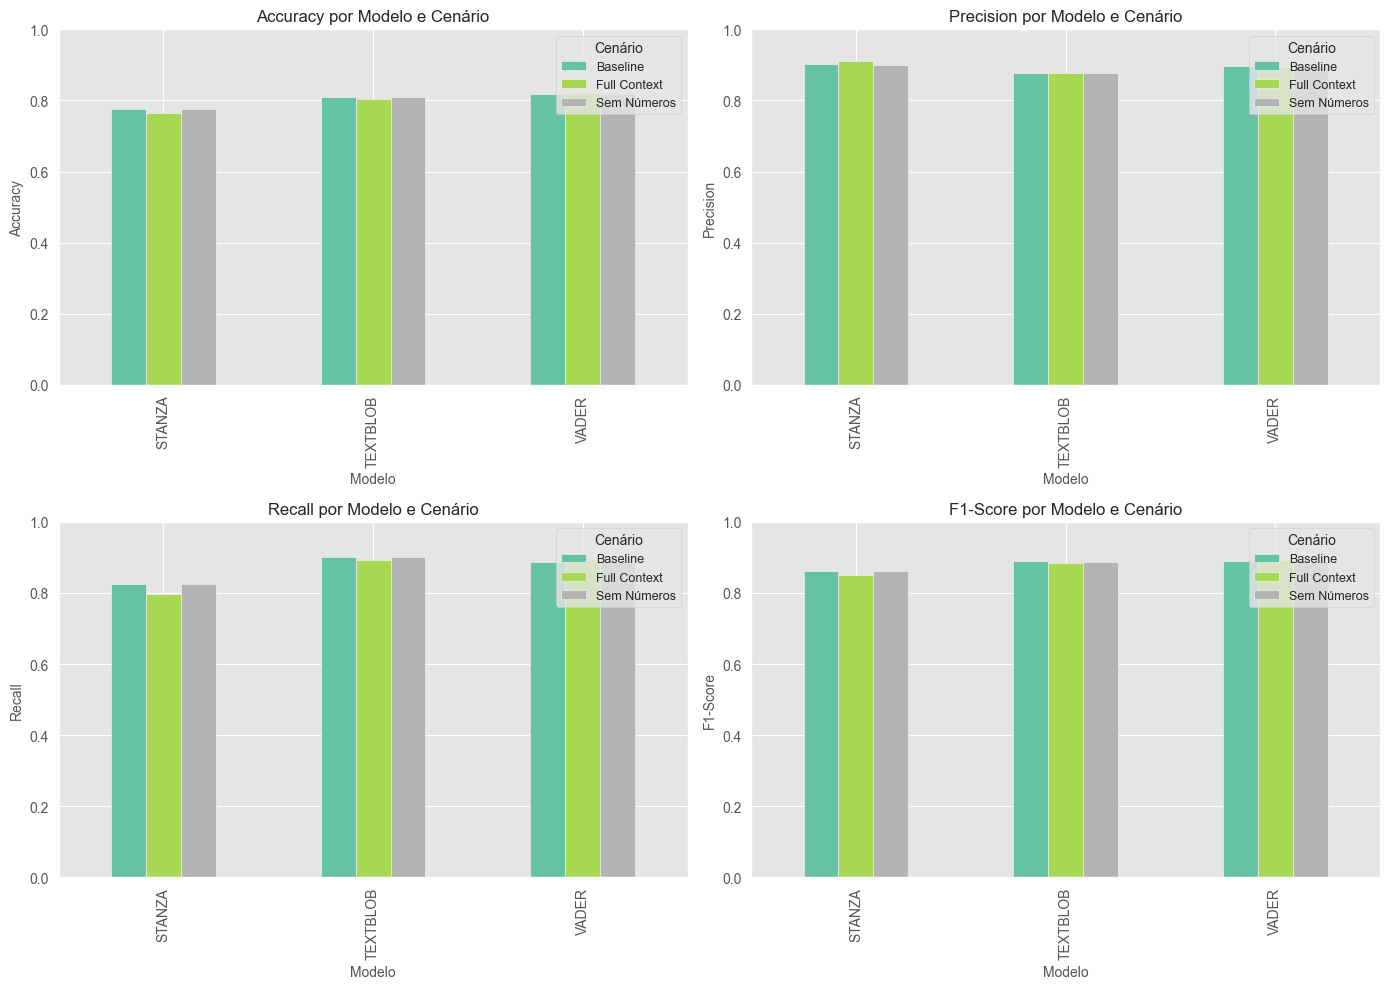

In [16]:
# Comparação por modelo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metrica in enumerate(metricas):
    ax = axes[idx // 2, idx % 2]

    pivot = df_resultados.pivot(index='Modelo', columns='Cenário', values=metrica)
    pivot.plot(kind='bar', ax=ax, colormap='Set2')

    ax.set_title(f'{metrica} por Modelo e Cenário', fontsize=12)
    ax.set_ylabel(metrica, fontsize=10)
    ax.set_xlabel('Modelo', fontsize=10)
    ax.legend(title='Cenário', fontsize=9)
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('comparacao_modelos_lexicos.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Melhor modelo por cenário
print("Melhores modelos por F1-Score:\n")
for cenario_nome in nomes_cenarios.values():
    melhor = df_resultados[df_resultados['Cenário'] == cenario_nome].nlargest(1, 'F1-Score')
    print(f"{cenario_nome}: {melhor['Modelo'].values[0]} - F1={melhor['F1-Score'].values[0]:.4f}")

Melhores modelos por F1-Score:

Baseline: VADER - F1=0.8906
Sem Números: VADER - F1=0.8906
Full Context: VADER - F1=0.8936
